In [ ]:
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import Image
from matplotlib.colors import Normalize


class DeepSet(nn.Module):
    def __init__(self, input_dim=6, phi_hidden_dim=8, phi_dim=1, rho_dim=8):
        super().__init__()
        self.phi = nn.Sequential(
            nn.Linear(input_dim, phi_hidden_dim),
            nn.ReLU(),
            nn.Linear(phi_hidden_dim, phi_dim),
            nn.ReLU(),
        )
        self.rho = nn.Sequential(
            nn.Linear(phi_dim, rho_dim),
            nn.ReLU(),
            nn.Linear(rho_dim, 1),
        )

    def forward(self, input_tensor):
        phi_values = self.phi(input_tensor)
        pooled = phi_values.sum(dim=1)
        return self.rho(pooled)


#
class FCNN(nn.Module):
    def __init__(self, input_dim=30, hidden_dim=13):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)


def make_training_data(num_examples, seed):
    rng = np.random.default_rng(seed)
    inputs_int = rng.integers(1, 7, size=(num_examples, 5))

    petals = np.where(inputs_int == 3, 2, 0) + np.where(inputs_int == 5, 4, 0)
    targets = petals.sum(axis=1)

    inputs_onehot = np.eye(6)[inputs_int - 1]

    inputs_tensor = torch.tensor(inputs_onehot, dtype=torch.float32)
    targets_tensor = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)

    return inputs_tensor, targets_tensor


def fit_model(num_examples, seed, epochs=2000, lr=0.001):
    torch.manual_seed(seed)

    train_inputs, train_targets = make_training_data(num_examples, seed)

    fitted_model = DeepSet()
    # fitted_model = FCNN()

    criterion = nn.MSELoss()
    optimizer = optim.Adam(fitted_model.parameters(), lr=lr)

    for _ in range(epochs):
        optimizer.zero_grad()
        predictions = fitted_model(train_inputs)
        loss = criterion(predictions, train_targets)
        loss.backward()
        optimizer.step()

    return fitted_model, float(loss.item())


def response_grid(fitted_model, grid_step=0.2):
    x0_values = np.arange(1, 6.01, grid_step)
    x1_values = np.arange(1, 6.01, grid_step)

    x0_grid, x1_grid = np.meshgrid(x0_values, x1_values)

    grid_points_int = np.column_stack(
        [
            np.rint(x0_grid.ravel()),
            np.rint(x1_grid.ravel()),
            np.ones(x0_grid.size),
            np.ones(x0_grid.size),
            np.ones(x0_grid.size),
        ]
    ).astype(int)

    grid_points_int = np.clip(grid_points_int, 1, 6)
    grid_points_onehot = np.eye(6)[grid_points_int - 1]
    grid_points_tensor = torch.tensor(grid_points_onehot, dtype=torch.float32)

    fitted_model.eval()
    with torch.no_grad():
        prediction_grid = (
            fitted_model(grid_points_tensor).numpy().reshape(x0_grid.shape)
        )

    return x0_grid, x1_grid, prediction_grid


def save_surface_frame(fitted_model, num_examples, loss_value, frame_path):
    x0_grid, x1_grid, prediction_grid = response_grid(fitted_model)

    norm = Normalize(vmin=0, vmax=20)

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        x0_grid,
        x1_grid,
        prediction_grid,
        cmap="viridis",
        norm=norm,
        linewidth=0,
        antialiased=False,
        shade=True,
    )

    ax.set_title(
        f"Fully-connected NN Response Surface, N={num_examples}, loss={loss_value:.4f}"
    )
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    ax.set_zlabel("prediction")

    ax.set_zlim(0, 20)
    ax.view_init(elev=25, azim=-135)
    ax.set_box_aspect((1, 1, 0.8))

    fig.colorbar(
        surf,
        ax=ax,
        shrink=0.65,
        pad=0.1,
        label="prediction",
    )

    plt.tight_layout()
    fig.savefig(frame_path, dpi=120)
    plt.close(fig)


# ------------------------------------------------------------------
# Train N=1..10, save frames, build animated GIF
# ------------------------------------------------------------------

frame_dir = Path("deepset_frames")
frame_dir.mkdir(exist_ok=True)

frame_paths = []

# for num_examples in range(5, 101, 5): # FCNN
for num_examples in range(1, 21):  # DeepSet
    fitted_model, loss_value = fit_model(
        num_examples=num_examples,
        seed=37,
        epochs=2000,
        lr=0.001,
    )

    frame_path = frame_dir / f"fcnn_N{num_examples:02d}.png"
    save_surface_frame(
        fitted_model=fitted_model,
        num_examples=num_examples,
        loss_value=loss_value,
        frame_path=frame_path,
    )

    frame_paths.append(frame_path)

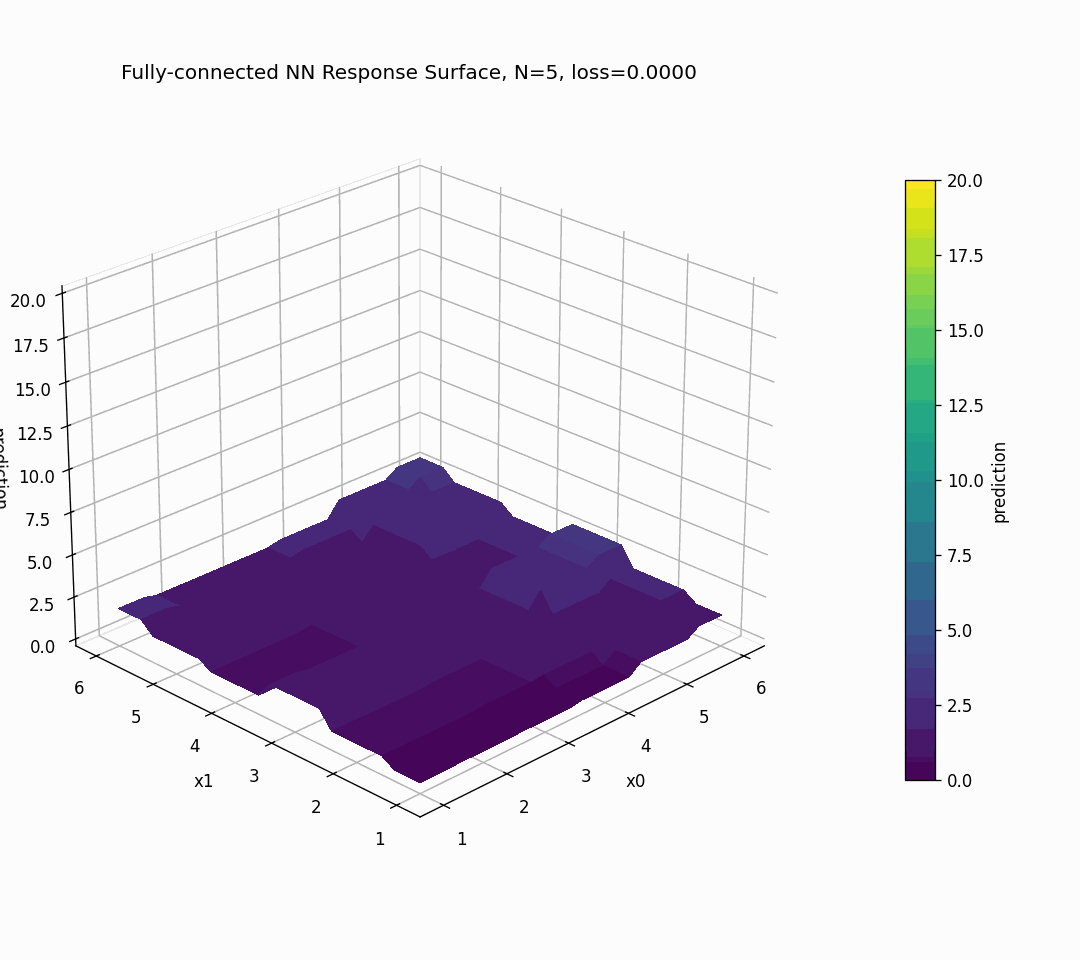

In [ ]:
gif_path = "deepset_animation.gif"

frames = [imageio.imread(path) for path in frame_paths]

imageio.mimsave(
    gif_path,
    frames,
    format="GIF",
    duration=1000,
    loop=0,
)

Image(filename=gif_path)